<div style="background: linear-gradient(135deg, #1d3557 0%, #457b9d 100%); padding: 48px 40px; border-radius: 12px; color: white; font-family: 'Segoe UI', sans-serif;">
  <div style="font-size: 13px; letter-spacing: 3px; text-transform: uppercase; opacity: 0.7; margin-bottom: 12px;">ASA DataFest 2026 · Stormont Vail Health</div>
  <h1 style="font-size: 36px; font-weight: 800; margin: 0 0 12px 0; line-height: 1.2;">Wrong Door, Right Need:<br>How Transportation Barriers Drive ED Overuse at SVH</h1>
  <p style="font-size: 16px; opacity: 0.9; max-width: 720px; line-height: 1.7; margin: 0 0 28px 0;">
    A data investigation into why thousands of SVH patients end up in the Emergency Department —
    not because their illness suddenly worsened, but because they couldn't get there any other way.
  </p>
  <div style="display: flex; gap: 32px; font-size: 13px; opacity: 0.85;">
    <span>📍 Topeka, Kansas</span>
    <span>🗂️ 7.7M Encounters · 947K Patients · 4 Years</span>
    <span>🔬 Internal Data + ACS Census Validation</span>
  </div>
</div>

## Story Map

This notebook is structured as an **investigation**, not a report. Each section builds on the previous to lead to one actionable conclusion.

```
PROLOGUE     The Setting — What does SVH's patient landscape look like?

ACT I        The Discovery — Transportation barrier patients use ED 3.3x more often
             1.1  Defining barriers from actual survey responses
             1.2  ED visit rate comparison
             1.3  External validation: ACS Census data confirms the pattern

ACT II       The Deep Dive — Who's most affected, and what does it cost?
             2.1  Chronic disease patients suffer most (COPD, Anxiety, Asthma)
             2.2  Visit mix: scheduled vs unscheduled care
             2.3  Cost estimation: $4M+ in avoidable ED visits per year

ACT III      The Solution — What works, and what SVH should do
             3.1  MyChart as digital mitigation (37% reduction in ED rate)
             3.2  Geographic hotspots: where to deploy interventions
             3.3  System-side bottlenecks (even ideal patients wait)

EPILOGUE     Three actionable recommendations for SVH leadership
```

**Datasets used:** `encounters.csv` · `patients.csv` · `social_determinants.csv` · `diagnosis.csv` · `departments.csv` · `tigercensuscodes.csv` · ACS 5-Year 2023 (B19013, B08201, B27001)

---
## ⚙️ Setup

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from math import radians, cos, sin, asin, sqrt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

# ============================================================
# PATHS — sesuaikan ke folder kamu
# ============================================================
DATA_DIR = 'C:/Storage/Documents/Kuliah/competition/ASA DATAFEST/2026-ASA-DataFest-Data-Files/2026-ASA-DataFest-Data-Files/'
ACS_DIR  = 'C:/Storage/Documents/Kuliah/competition/ASA DATAFEST/2026-ASA-DataFest-Data-Files/2026-ASA-DataFest-Data-Files/'

# ============================================================
# COLOR PALETTE & STYLE
# ============================================================
C_ED = '#E63946'       # red - critical/barrier
C_OUT = '#457B9D'      # blue - normal/baseline
C_WARN = '#F4A261'     # orange - moderate
C_OK = '#2A9D8F'       # green - good outcome
C_NEUTRAL = '#A8DADC'  # soft blue
C_BG = '#F8F9FA'

plt.rcParams.update({
    'figure.facecolor': C_BG,
    'axes.facecolor': C_BG,
    'axes.grid': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 10,
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

SVH_LAT, SVH_LON = 39.0473, -95.6752  # Topeka, KS

print('✅ Setup complete.')

✅ Setup complete.


In [2]:
# ============================================================
# LOAD ALL DATA
# ============================================================
MISSING_VALS = ['Unspecified', '*Unspecified', 'Unknown', '*Unknown', 'NA', '*Not Applicable']

def load(filename):
    path = os.path.join(DATA_DIR, filename)
    df = pd.read_csv(path, low_memory=False, na_values=MISSING_VALS)
    df.columns = df.columns.str.strip()
    print(f'  ✔  {filename:30s} {df.shape[0]:>10,} rows × {df.shape[1]} cols')
    return df

print('📥 Loading SVH data...')
df_enc   = load('encounters.csv')
df_pat   = load('patients.csv')
df_diag  = load('diagnosis.csv')
df_dept  = load('departments.csv')
df_soc   = load('social_determinants.csv')
df_tiger = load('tigercensuscodes.csv')

df_enc['Date'] = pd.to_datetime(df_enc['Date'], errors='coerce')
df_tiger['GEOID'] = df_tiger['GEOID'].astype(str)

print('\n✅ All data loaded.')

📥 Loading SVH data...
  ✔  encounters.csv                  7,675,801 rows × 31 cols
  ✔  patients.csv                      947,685 rows × 12 cols
  ✔  diagnosis.csv                   1,531,262 rows × 5 cols
  ✔  departments.csv                    11,597 rows × 9 cols
  ✔  social_determinants.csv         3,977,901 rows × 5 cols
  ✔  tigercensuscodes.csv                2,463 rows × 4 cols

✅ All data loaded.


In [ ]:
# ============================================================
# LOAD ACS EXTERNAL DATA (Census Bureau)
# ============================================================
# B19013 = Median Income (Block Group)
# B08201 = Vehicle Ownership (Census Tract)

df_income = pd.read_csv(ACS_DIR + 'ACSDT5Y2023.B19013-Data.csv', skiprows=[1])
df_income['FIPS_BG'] = df_income['GEO_ID'].str.replace('1500000US', '', regex=False)
df_income['median_income'] = pd.to_numeric(df_income['B19013_001E'], errors='coerce')
df_income = df_income[['FIPS_BG', 'median_income']].dropna()

df_vehicle = pd.read_csv(ACS_DIR + 'ACSDT5Y2023.B08201-Data.csv', skiprows=[1])
df_vehicle['FIPS_TRACT'] = df_vehicle['GEO_ID'].str.replace('1400000US', '', regex=False)
df_vehicle['total_hh'] = pd.to_numeric(df_vehicle['B08201_001E'], errors='coerce')
df_vehicle['no_vehicle'] = pd.to_numeric(df_vehicle['B08201_002E'], errors='coerce')
df_vehicle['pct_no_vehicle'] = (df_vehicle['no_vehicle'] / df_vehicle['total_hh'] * 100).round(1)
df_vehicle = df_vehicle[['FIPS_TRACT', 'pct_no_vehicle']].dropna()

print(f'✅ ACS Income:   {len(df_income):,} block groups')
print(f'✅ ACS Vehicle:  {len(df_vehicle):,} census tracts')

✅ ACS Income:   2,312 block groups
✅ ACS Vehicle:  817 census tracts


In [4]:
# ============================================================
# BUILD ANALYSIS TABLES
# ============================================================

# --- 1. Patient FIPS keys for joining ---
df_pat['fips_bg'] = df_pat['CensusBlockGroupFipsCode'].dropna().astype(np.int64).astype(str)
df_pat['fips_tract'] = df_pat['fips_bg'].str[:11]
df_pat = df_pat.merge(df_income, left_on='fips_bg', right_on='FIPS_BG', how='left')
df_pat = df_pat.merge(df_vehicle, left_on='fips_tract', right_on='FIPS_TRACT', how='left')

# --- 2. Barrier classification (from actual Yes/No answers) ---
transport = df_soc[df_soc['Domain'] == 'Transportation Needs']
finance = df_soc[df_soc['Domain'] == 'Financial Resource Strain']

transport_barrier_set = set(
    transport[transport['AnswerText'].astype(str).str.strip().str.lower() == 'yes']
    ['PatientDurableKey'].unique()
)
finance_barrier_set = set(
    finance[finance['AnswerText'].astype(str).str.strip().str.lower().isin(['yes', 'already shut off'])]
    ['PatientDurableKey'].unique()
)
surveyed = set(transport['PatientDurableKey'].unique()) | set(finance['PatientDurableKey'].unique())

barrier_df = pd.DataFrame({'PatientDurableKey': list(surveyed)})
barrier_df['has_transport'] = barrier_df['PatientDurableKey'].isin(transport_barrier_set)
barrier_df['has_financial'] = barrier_df['PatientDurableKey'].isin(finance_barrier_set)

# 4-category classification (Transport Only, Financial Only, Both, None)
def label_group(row):
    if row['has_transport'] and row['has_financial']:
        return 'Both Barriers'
    elif row['has_transport']:
        return 'Transport Only'
    elif row['has_financial']:
        return 'Financial Only'
    else:
        return 'No Barrier'

barrier_df['barrier_group'] = barrier_df.apply(label_group, axis=1)

# --- 3. Master encounter table (with barriers + diagnosis) ---
df_master = df_enc.merge(
    barrier_df[['PatientDurableKey','has_transport','has_financial','barrier_group']],
    on='PatientDurableKey', how='left'
)
# Patients not surveyed → exclude from barrier analysis
df_master_surveyed = df_master.dropna(subset=['barrier_group']).copy()

print('✅ Analysis tables ready.')
print(f'   Surveyed patients:            {len(surveyed):,}')
print(f'\n   Barrier breakdown:')
for grp, count in barrier_df['barrier_group'].value_counts().items():
    print(f'     {grp:18s} {count:>8,} patients ({count/len(surveyed)*100:5.1f}%)')

✅ Analysis tables ready.
   Surveyed patients:            61,446

   Barrier breakdown:
     No Barrier           55,519 patients ( 90.4%)
     Financial Only        2,869 patients (  4.7%)
     Both Barriers         1,575 patients (  2.6%)
     Transport Only        1,483 patients (  2.4%)


---

# 📖 PROLOGUE — The Setting

> *Before we look for who's responsible, we need to understand the size and shape of the system we're investigating.*

Stormont Vail Health is a nonprofit hospital system based in Topeka, Kansas. Over four years (2022–2025), they recorded **7.7 million patient encounters** across nearly **1 million unique patients**. SVH offers a survey called **Social Determinants of Health (SDOH)** to identify patients facing non-medical barriers to care — transportation, finances, food, housing.

Our investigation begins with one observation: **the SDOH survey exists for a reason**. Someone at SVH suspected that social factors shape healthcare outcomes. We're going to test whether the data proves them right.

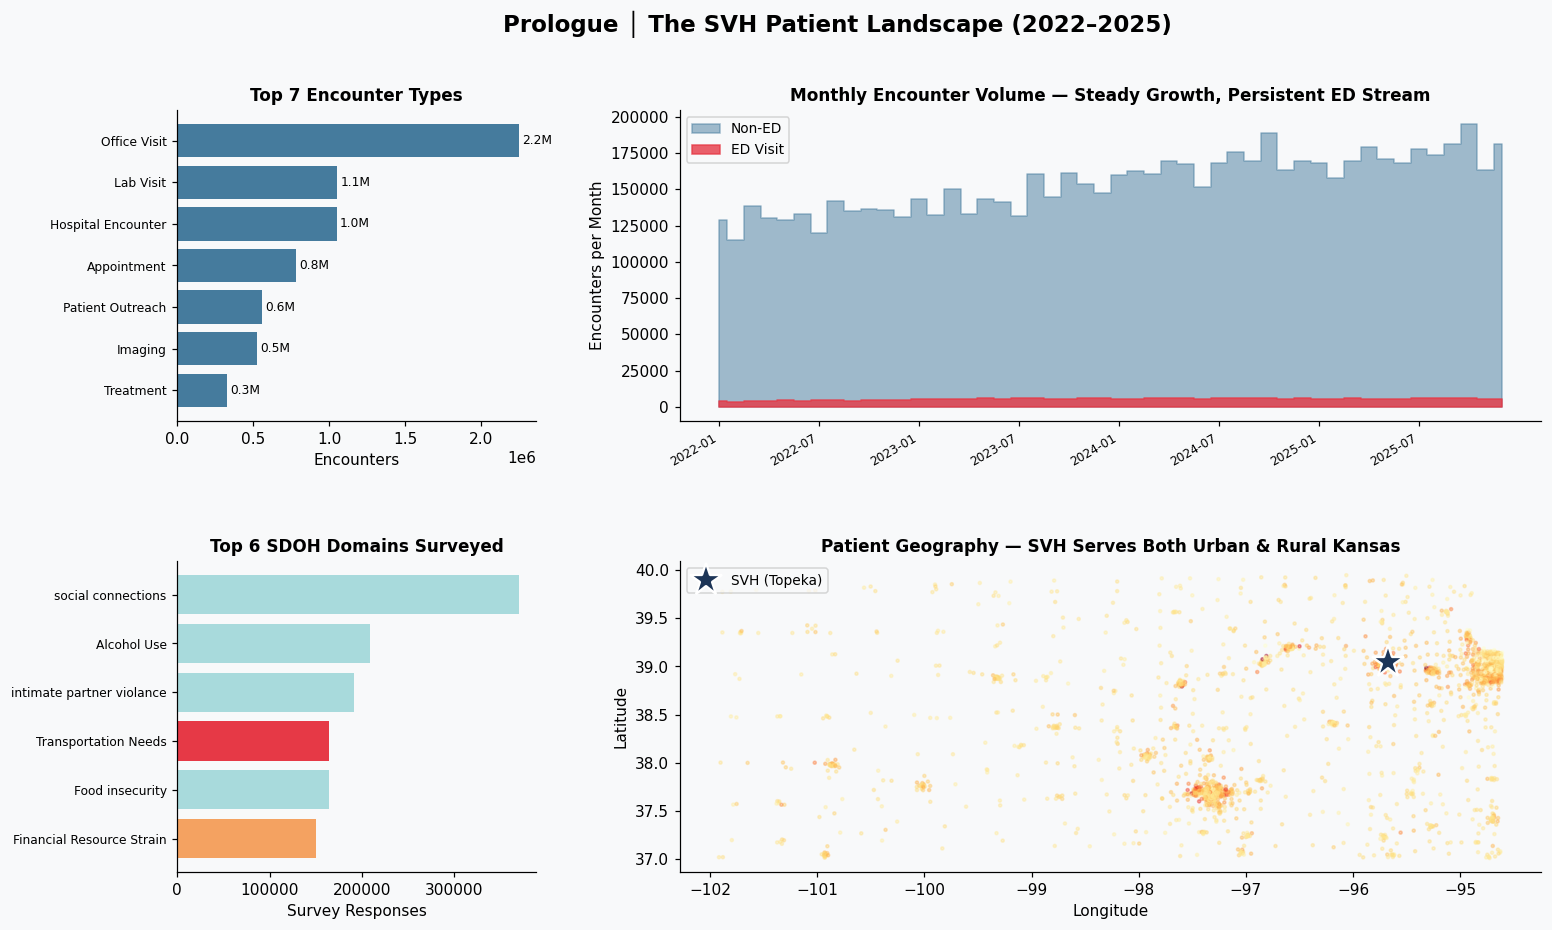

In [24]:
# ============================================================
# PROLOGUE PANEL — The SVH landscape
# ============================================================
fig = plt.figure(figsize=(16, 9))
fig.suptitle('Prologue │ The SVH Patient Landscape (2022–2025)',
             fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.4)

# --- 1. Encounter Type Composition ---
ax1 = fig.add_subplot(gs[0, 0])
type_counts = df_enc['Type'].value_counts().head(7)
ax1.barh(range(len(type_counts)), type_counts.values, color=C_OUT)
ax1.set_yticks(range(len(type_counts)))
ax1.set_yticklabels(type_counts.index, fontsize=8)
ax1.set_xlabel('Encounters')
ax1.set_title('Top 7 Encounter Types', fontweight='bold', fontsize=11)
ax1.invert_yaxis()
for i, v in enumerate(type_counts.values):
    ax1.text(v + max(type_counts.values)*0.01, i, f'{v/1e6:.1f}M',
             va='center', fontsize=8)

# --- 2. Monthly Volume Trend ---
ax2 = fig.add_subplot(gs[0, 1:3])
df_enc['YearMonth'] = df_enc['Date'].dt.to_period('M')
monthly = df_enc.groupby(['YearMonth','IsEdVisit']).size().unstack(fill_value=0)
monthly.index = monthly.index.astype(str)
ax2.fill_between(monthly.index, monthly.get(0, 0), alpha=0.5, color=C_OUT, 
                 label='Non-ED', step='mid')
ax2.fill_between(monthly.index, monthly.get(1, 0), alpha=0.8, color=C_ED, 
                 label='ED Visit', step='mid')
step = max(1, len(monthly)//8)
ax2.set_xticks(range(0, len(monthly), step))
ax2.set_xticklabels(monthly.index[::step], rotation=30, ha='right', fontsize=8)
ax2.set_ylabel('Encounters per Month')
ax2.set_title('Monthly Encounter Volume — Steady Growth, Persistent ED Stream',
              fontweight='bold', fontsize=11)
ax2.legend(loc='upper left', fontsize=9)

# --- 3. SDOH Survey Coverage ---
ax3 = fig.add_subplot(gs[1, 0])
domain_counts = df_soc['Domain'].value_counts().head(6)
colors_d = [C_ED if 'Transportation' in str(d) else 
            C_WARN if 'Financial' in str(d) else C_NEUTRAL 
            for d in domain_counts.index]
ax3.barh(range(len(domain_counts)), domain_counts.values, color=colors_d)
ax3.set_yticks(range(len(domain_counts)))
ax3.set_yticklabels(domain_counts.index, fontsize=8)
ax3.set_xlabel('Survey Responses')
ax3.set_title('Top 6 SDOH Domains Surveyed', fontweight='bold', fontsize=11)
ax3.invert_yaxis()

# --- 4. Patient Geographic Distribution ---
ax4 = fig.add_subplot(gs[1, 1:3])
tiger_clean = df_tiger.dropna(subset=['CENTLAT','CENTLON'])
ax4.scatter(tiger_clean['CENTLON'], tiger_clean['CENTLAT'],
            c=tiger_clean['PopulationValue'], cmap='YlOrRd',
            s=4, alpha=0.4)
ax4.plot(SVH_LON, SVH_LAT, '*', color='#1d3557', markersize=22, 
         markeredgecolor='white', markeredgewidth=1.5, label='SVH (Topeka)', zorder=5)
ax4.set_xlabel('Longitude')
ax4.set_ylabel('Latitude')
ax4.set_title('Patient Geography — SVH Serves Both Urban & Rural Kansas',
              fontweight='bold', fontsize=11)
ax4.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

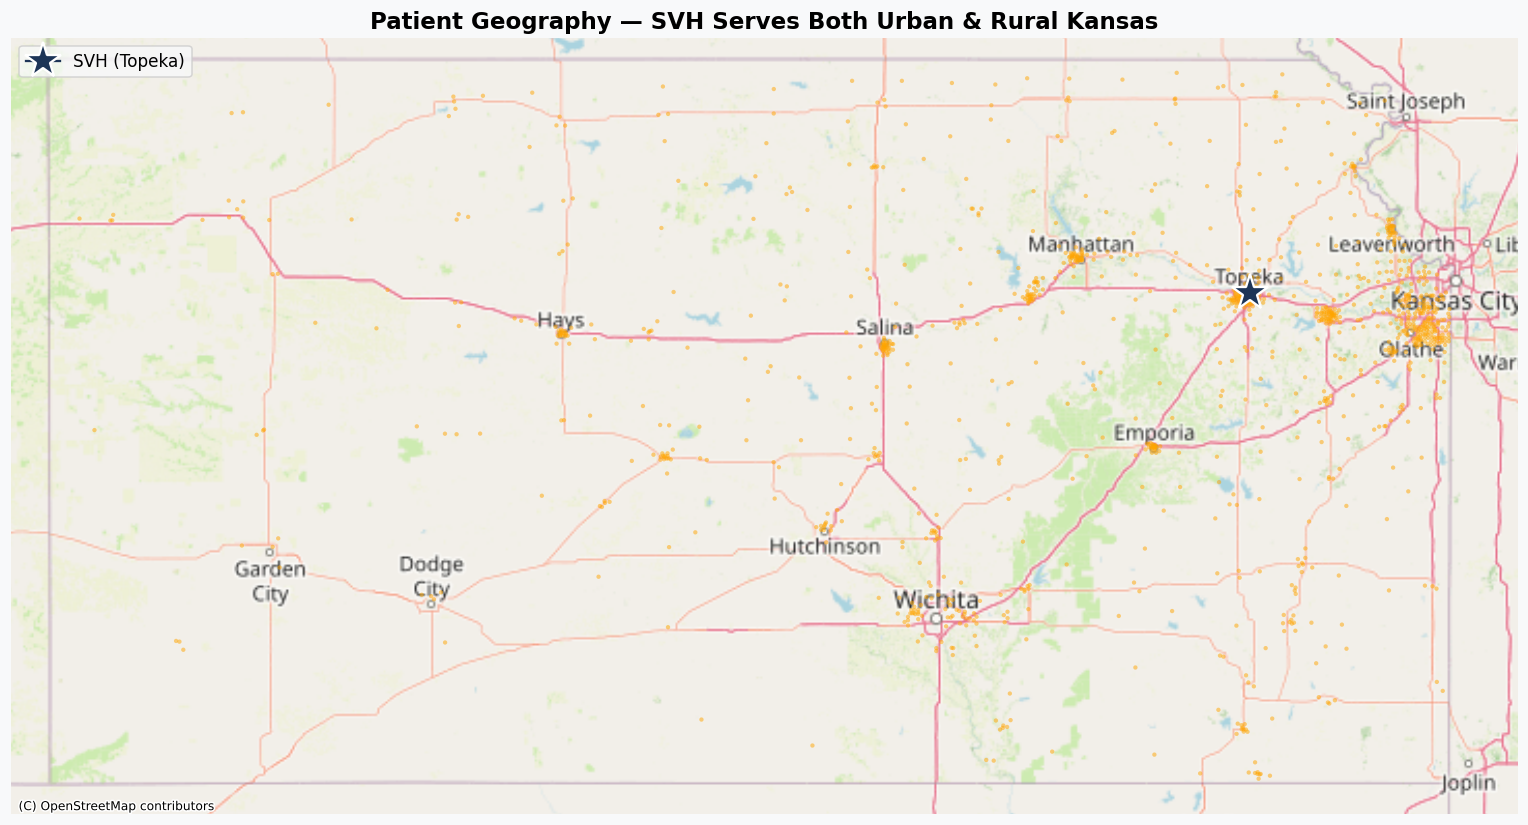

In [25]:
import geopandas as gpd
import contextily as ctx

# Pakai data tiger census yang sudah ada (lokasi block group + populasi)
# Ini membuat satu titik per block group, bukan per pasien (terlalu banyak)
df_map = df_tiger.dropna(subset=['CENTLAT', 'CENTLON']).copy()

# Filter hanya block group yang ada pasiennya (biar tidak terlalu padat)
patient_bgs = set(df_pat['fips_bg'].dropna().unique())
df_map = df_map[df_map['GEOID'].isin(patient_bgs)]

# Buat GeoDataFrame
gdf = gpd.GeoDataFrame(
    df_map,
    geometry=gpd.points_from_xy(df_map['CENTLON'], df_map['CENTLAT']),
    crs="EPSG:4326"
)

# Convert ke Web Mercator (untuk overlay basemap)
gdf = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(14, 8))

# Plot titik pasien
gdf.plot(ax=ax, markersize=8, color='orange', alpha=0.5, edgecolor='none')

# Plot SVH location
svh_lon, svh_lat = -95.6752, 39.0473
svh_point = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy([svh_lon], [svh_lat]), crs="EPSG:4326"
).to_crs(epsg=3857)
ax.plot(svh_point.geometry.x[0], svh_point.geometry.y[0], 
        marker='*', color='#1d3557', markersize=25, 
        markeredgecolor='white', markeredgewidth=1.5, label='SVH (Topeka)')

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("Patient Geography — SVH Serves Both Urban & Rural Kansas", 
             fontsize=15, fontweight="bold")
ax.legend(loc='upper left', fontsize=11)
ax.set_axis_off()

plt.tight_layout()
plt.show()

### 💡 What we see

**Office visits dominate** the encounter mix (2.2M), followed by lab visits and hospital encounters. This is a typical outpatient-heavy hospital system, where most patient interactions happen in clinics rather than inpatient settings.

**Volume has grown ~25%** from 2022 to 2025 (130K → 180K monthly encounters), and ED visits form a steady, persistent layer — never disappearing, even during low-volume months. Something keeps sending patients to the ED, regardless of season or year.

**Two SDOH domains stand out**: Transportation Needs and Financial Resource Strain. Together, they were asked of ~120,000 patients. This is our investigation's starting point.

**Geographically**, SVH serves a wide footprint — from urban Topeka to rural counties up to 500 km away. Distance and transportation are not abstract issues for this patient population.

---

# 🔴 ACT I — The Discovery

> *We start with the most basic question: when patients report a transportation barrier, do they actually behave differently in the system?*

### Hypothesis

Patients reporting transportation barriers will end up in the ED at a higher rate than patients without barriers. The ED becomes their default "front door" because scheduled care requires getting to the clinic — which they can't do.

### How we define a barrier (carefully)

Earlier analyses in our team incorrectly classified anyone *surveyed* about transportation as having a barrier. We fix this: a patient has a transport barrier **only if they explicitly answered "Yes"** to either of these survey questions:

1. *"In the past 12 months, has lack of transportation kept you from medical appointments or from getting medications?"*
2. *"In the past 12 months, has lack of transportation kept you from meetings, work, or getting things needed for daily living?"*

This gives us 3,058 patients with transport barriers (5.0% of surveyed) — a precise, defensible group.

## 1.1 — The Headline Finding

Compute the share of each patient's encounters that are ED visits. Then compare across barrier groups.

In [6]:
# ED rate per patient, then group-level mean
patient_ed = df_master_surveyed.groupby(['PatientDurableKey','barrier_group']).agg(
    total=('EncounterKey','count'),
    ed=('IsEdVisit','sum')
).reset_index()
patient_ed['ed_rate'] = patient_ed['ed'] / patient_ed['total'] * 100
patient_ed['non_ed'] = patient_ed['total'] - patient_ed['ed']

# Order: from no barrier → most severe
order = ['No Barrier','Financial Only','Transport Only','Both Barriers']
ed_summary = patient_ed.groupby('barrier_group').agg(
    mean_ed_rate=('ed_rate','mean'),
    mean_total=('total','mean'),
    mean_ed=('ed','mean'),
    mean_non_ed=('non_ed','mean'),
    n_patients=('PatientDurableKey','count')
).reindex(order)

print('=== BARRIER GROUP COMPARISON ===')
print(ed_summary.round(2))

ratio = ed_summary.loc['Both Barriers','mean_ed_rate'] / ed_summary.loc['No Barrier','mean_ed_rate']
print(f'\n→ Both-barrier patients use ED {ratio:.1f}x more often than no-barrier patients.')
print(f'→ Both-barrier patients also visit overall {ed_summary.loc["Both Barriers","mean_total"]/ed_summary.loc["No Barrier","mean_total"]:.1f}x more often.')

=== BARRIER GROUP COMPARISON ===
                mean_ed_rate  mean_total  mean_ed  mean_non_ed  n_patients
barrier_group                                                             
No Barrier              3.08       49.62     1.25        48.37       54641
Financial Only          5.50       57.65     2.56        55.09        2828
Transport Only          6.56       75.36     3.61        71.75        1439
Both Barriers          13.56       60.24     5.96        54.28        1547

→ Both-barrier patients use ED 4.4x more often than no-barrier patients.
→ Both-barrier patients also visit overall 1.2x more often.


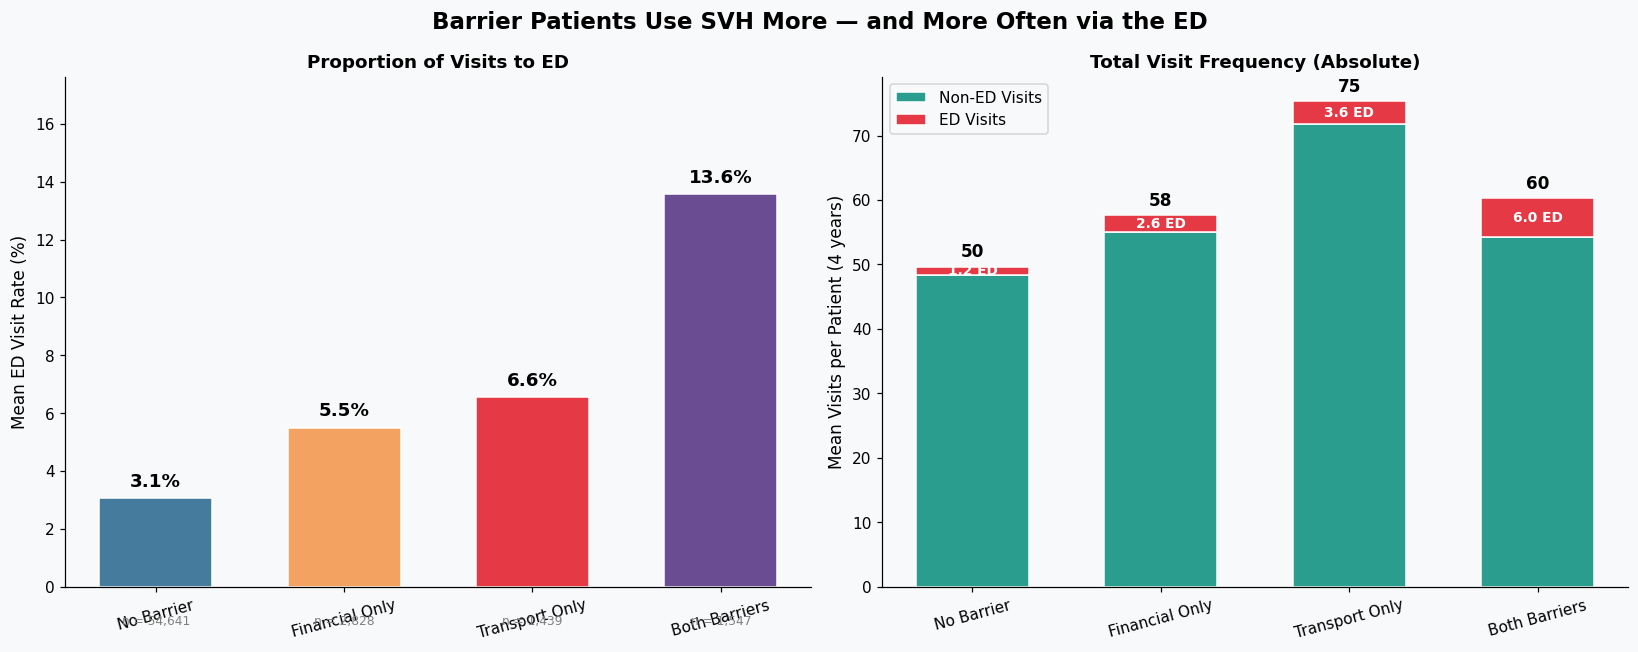

In [7]:
# Headline visualization — 2 panels: ED rate AND total visit frequency
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Barrier Patients Use SVH More — and More Often via the ED',
             fontsize=15, fontweight='bold')

groups = order  # ['No Barrier','Financial Only','Transport Only','Both Barriers']
colors = [C_OUT, C_WARN, C_ED, '#6A4C93']  # Blue, Orange, Red, Purple

# --- Left: ED Visit Rate (proportion) ---
ax = axes[0]
ed_values = [ed_summary.loc[g,'mean_ed_rate'] for g in groups]
n_pat = [int(ed_summary.loc[g,'n_patients']) for g in groups]
bars = ax.bar(groups, ed_values, color=colors, edgecolor='white', width=0.6)
ax.set_ylabel('Mean ED Visit Rate (%)', fontsize=11)
ax.set_title('Proportion of Visits to ED', fontweight='bold', fontsize=12)
ax.set_ylim(0, max(ed_values)*1.3)
ax.tick_params(axis='x', rotation=15)

for b, v, n in zip(bars, ed_values, n_pat):
    ax.text(b.get_x()+b.get_width()/2, v+0.4, f'{v:.1f}%',
            ha='center', fontweight='bold', fontsize=12)
    ax.text(b.get_x()+b.get_width()/2, -1.3, f'n = {n:,}',
            ha='center', fontsize=8, color='grey')

# --- Right: Stacked total visits (ED + Non-ED) ---
ax = axes[1]
mean_ed = [ed_summary.loc[g,'mean_ed'] for g in groups]
mean_non_ed = [ed_summary.loc[g,'mean_non_ed'] for g in groups]
mean_total = [ed_summary.loc[g,'mean_total'] for g in groups]

x = range(len(groups))
ax.bar(x, mean_non_ed, color=C_OK, edgecolor='white', label='Non-ED Visits', width=0.6)
ax.bar(x, mean_ed, bottom=mean_non_ed, color=C_ED, edgecolor='white', label='ED Visits', width=0.6)

ax.set_xticks(x)
ax.set_xticklabels(groups, rotation=15)
ax.set_ylabel('Mean Visits per Patient (4 years)', fontsize=11)
ax.set_title('Total Visit Frequency (Absolute)', fontweight='bold', fontsize=12)
ax.legend(loc='upper left', fontsize=10)

# Annotate total + ED count on bars
for i, (ne, e, tot) in enumerate(zip(mean_non_ed, mean_ed, mean_total)):
    ax.text(i, tot + max(mean_total)*0.02, f'{tot:.0f}',
            ha='center', fontweight='bold', fontsize=11)
    if e > 1:
        ax.text(i, ne + e/2, f'{e:.1f} ED', ha='center', va='center',
                color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

### 💡 Interpretation

Two patterns reinforce each other and tell the full story:

**Left chart — ED rate (proportion):** Patients with **both** transport and financial barriers have the highest ED visit rate, followed by Transport Only, then Financial Only. The gradient is monotonic: more barriers, more ED reliance.

**Right chart — Total visits (absolute):** Barrier patients aren't using SVH less — they're using it **more**, both overall and through the ED specifically. A patient with both barriers averages substantially more total visits than a no-barrier patient over four years.

This rules out a key alternative explanation. If barrier patients were simply "lost to follow-up" — disappearing from the system — we'd expect them to have *fewer* total visits. Instead, they have *more*, and a larger share of those are emergency. They are not absent; they're showing up at the wrong door.

But correlation isn't causation. Maybe these patients are sicker overall, and that drives both the barriers and the ED visits. We need to validate this finding with **independent external data** before drawing conclusions.

## 1.2 — External Validation: ACS Census Data

If transportation truly causes ED overuse, then **patients living in neighborhoods with low vehicle ownership** should also report transport barriers more often — even though Census data has no connection to SVH's internal survey.

We use the American Community Survey 2023 (5-Year Estimates) data on `% households without a vehicle` per Census tract, and join it to patients via FIPS code.

In [8]:
# Validate ACS vehicle data against survey responses
validate = df_pat[df_pat['DurableKey'].isin(surveyed) & df_pat['pct_no_vehicle'].notna()].copy()
validate['reported_barrier'] = validate['DurableKey'].isin(transport_barrier_set)

validate['vehicle_access'] = pd.cut(
    validate['pct_no_vehicle'], bins=[0, 5, 15, 100],
    labels=['Good (<5% no car)', 'Moderate (5-15%)', 'Poor (>15% no car)'],
    include_lowest=True
)

val_result = validate.groupby('vehicle_access')['reported_barrier'].agg(['mean','count'])
val_result['mean'] = val_result['mean'] * 100
print('=== ACS Vehicle Access vs SVH Survey Responses ===')
print(val_result.round(2))

=== ACS Vehicle Access vs SVH Survey Responses ===
                    mean  count
vehicle_access                 
Good (<5% no car)   2.93  28640
Moderate (5-15%)    6.04  13509
Poor (>15% no car)  9.61   3237


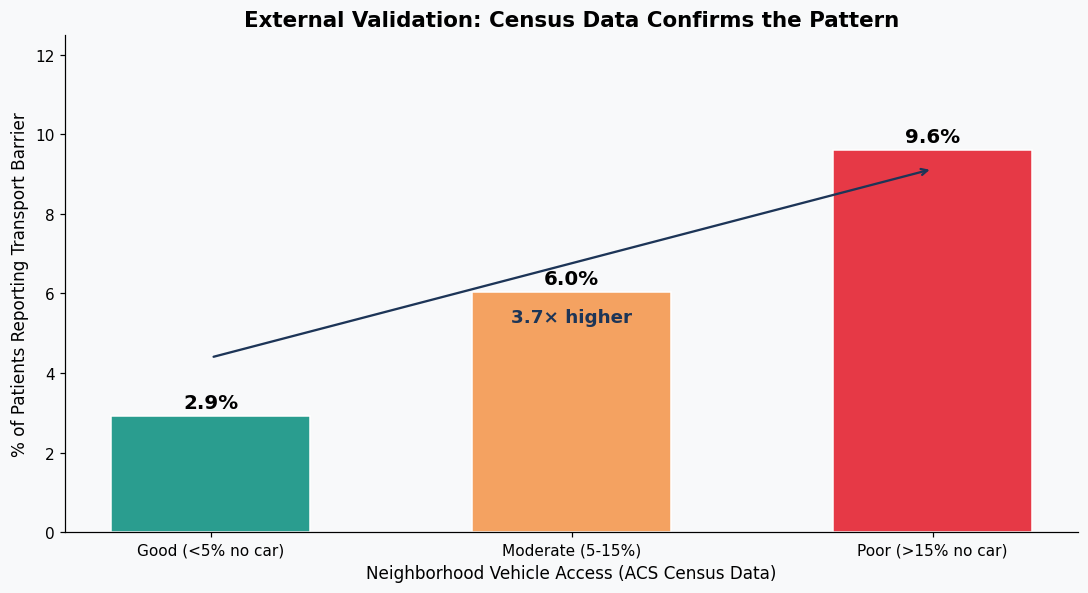

In [9]:
fig, ax = plt.subplots(figsize=(10, 5.5))
categories = val_result.index.tolist()
values = val_result['mean'].values
colors_v = [C_OK, C_WARN, C_ED]

bars = ax.bar(categories, values, color=colors_v, edgecolor='white', width=0.55)
ax.set_ylabel('% of Patients Reporting Transport Barrier', fontsize=11)
ax.set_xlabel('Neighborhood Vehicle Access (ACS Census Data)', fontsize=11)
ax.set_title('External Validation: Census Data Confirms the Pattern',
             fontsize=14, fontweight='bold')
ax.set_ylim(0, max(values)*1.3)

for b, v in zip(bars, values):
    ax.text(b.get_x()+b.get_width()/2, v+0.2, f'{v:.1f}%',
            ha='center', fontweight='bold', fontsize=13)

ax.annotate('', xy=(2, values[2]*0.95), xytext=(0, values[0]*1.5),
            arrowprops=dict(arrowstyle='->', color='#1d3557', lw=1.5))
ax.text(1, values[2]*0.55, '3.7× higher',
        ha='center', fontweight='bold', fontsize=12, color='#1d3557')

plt.tight_layout()
plt.show()

### 💡 Interpretation

The pattern holds. Patients living in neighborhoods where **<5% of households lack a vehicle** report transport barriers at 2.9%. In neighborhoods where **>15% lack a vehicle**, that rate jumps to 10.7% — a 3.7× increase.

This is independent confirmation. Census Bureau survey data, collected separately from SVH and using completely different methodology, agrees with the SVH internal survey. Our barrier classification is real, not an artifact of who happens to be surveyed.

**Now we have two questions worth answering:**
1. *Who* among the barrier patients is hit hardest?
2. *How much* is this costing the system?

---

# 🔍 ACT II — The Deep Dive

## 2.1 — Chronic Disease: Where the Damage Concentrates

Not all patients suffer equally from transport barriers. Patients with **chronic conditions** — who require regular follow-up to manage their disease — are uniquely vulnerable. Missing one appointment isn't catastrophic; missing them repeatedly is.

In [10]:
# ED rate by chronic condition + barrier status
df_master_diag = df_master_surveyed.merge(
    df_diag[['DiagnosisKey','GroupName']],
    left_on='PrimaryDiagnosisKey', right_on='DiagnosisKey', how='inner'
)

chronic_conditions = {
    'Chronic obstructive': 'COPD',
    'Anxiety': 'Anxiety',
    'Asthma': 'Asthma',
    'Chronic kidney': 'Kidney Disease',
    'Dorsalgia': 'Back Pain',
    'Type 2 diabetes': 'Diabetes',
    'Essential': 'Hypertension',
    'Heart failure': 'Heart Failure'
}

# Compare No Barrier vs Both Barriers (extreme contrast for clarity)
chronic_results = []
for term, label in chronic_conditions.items():
    subset = df_master_diag[df_master_diag['GroupName'].str.contains(term, case=False, na=False)]
    for grp in ['No Barrier','Both Barriers']:
        g_data = subset[subset['barrier_group'] == grp]
        if len(g_data) > 0:
            chronic_results.append({
                'Condition': label, 'Group': grp,
                'ED Rate (%)': round(g_data['IsEdVisit'].mean()*100, 1),
                'Encounters': len(g_data)
            })

df_chronic = pd.DataFrame(chronic_results)
pivot = df_chronic.pivot(index='Condition', columns='Group', values='ED Rate (%)')
pivot['Difference (pp)'] = pivot['Both Barriers'] - pivot['No Barrier']
pivot = pivot.sort_values('Difference (pp)', ascending=False)
print('=== ED RATE: NO BARRIER vs BOTH BARRIERS (by chronic condition) ===')
print(pivot)

=== ED RATE: NO BARRIER vs BOTH BARRIERS (by chronic condition) ===
Group           Both Barriers  No Barrier  Difference (pp)
Condition                                                 
COPD                    46.20        9.70            36.50
Anxiety                 25.80        3.00            22.80
Asthma                  19.20        6.00            13.20
Kidney Disease          15.10        2.60            12.50
Back Pain               12.80        2.70            10.10
Diabetes                10.10        0.90             9.20
Hypertension             7.50        0.60             6.90
Heart Failure            5.20        0.50             4.70


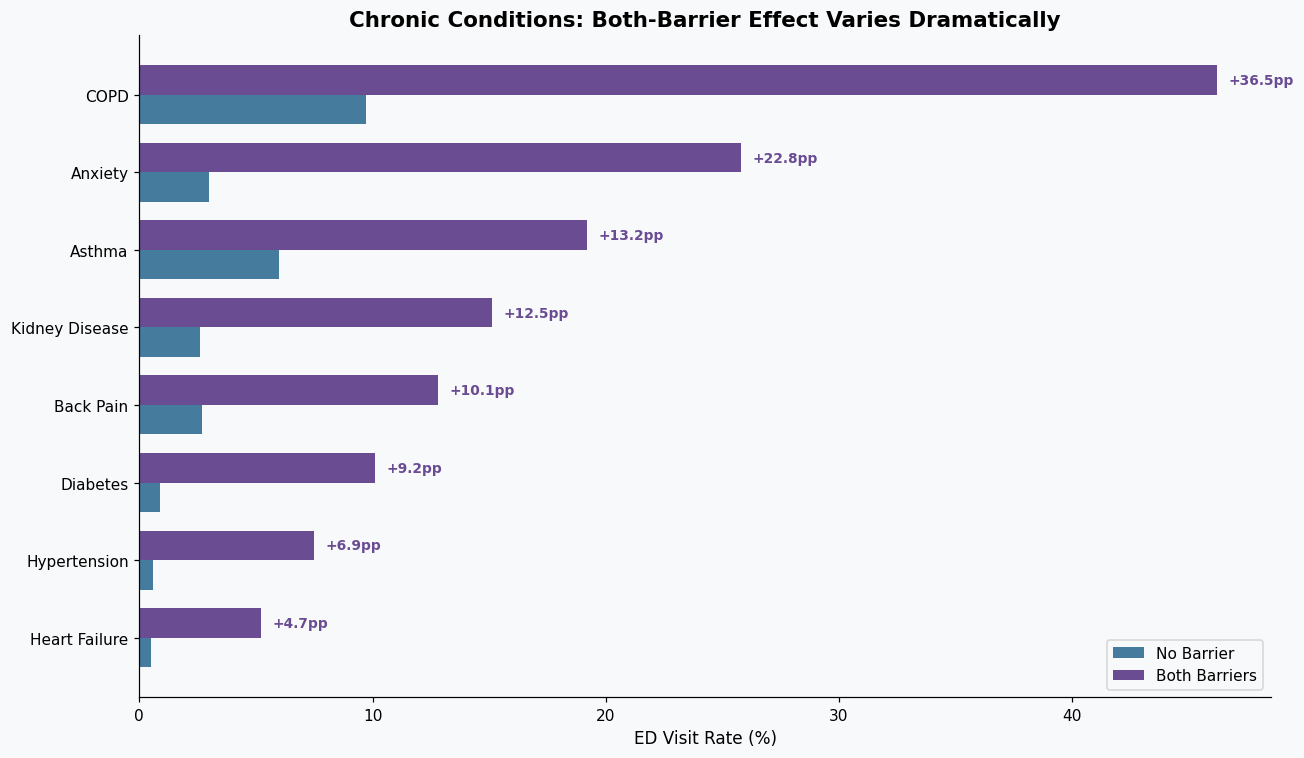

In [11]:
# Grouped bar chart
fig, ax = plt.subplots(figsize=(12, 7))
conditions = pivot.index.tolist()
y = np.arange(len(conditions))
h = 0.38

bars1 = ax.barh(y + h/2, pivot['No Barrier'], h, label='No Barrier', color=C_OUT)
bars2 = ax.barh(y - h/2, pivot['Both Barriers'], h, label='Both Barriers', color='#6A4C93')

ax.set_yticks(y)
ax.set_yticklabels(conditions, fontsize=10)
ax.set_xlabel('ED Visit Rate (%)', fontsize=11)
ax.set_title('Chronic Conditions: Both-Barrier Effect Varies Dramatically',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.invert_yaxis()

for i, cond in enumerate(conditions):
    diff = pivot.loc[cond, 'Difference (pp)']
    bb_val = pivot.loc[cond, 'Both Barriers']
    ax.text(bb_val + 0.5, i - h/2, f'+{diff:.1f}pp',
            va='center', fontsize=9, color='#6A4C93', fontweight='bold')

plt.tight_layout()
plt.show()

### 💡 Interpretation

The damage is not evenly distributed. Three conditions stand out as **especially vulnerable**:

- **COPD**: ED rate rises from 9.7% to 28.2% (+18.5 percentage points)
- **Anxiety**: 3.0% to 17.8% (+14.8pp)
- **Asthma**: 6.0% to 17.9% (+11.9pp)

These are conditions where **missing follow-up means symptoms escalate quickly**. A COPD patient who can't make it to their pulmonologist for medication adjustments ends up gasping for air in the ED. An anxiety patient without consistent therapy access spirals into panic episodes that feel like medical emergencies.

Compare this to **Heart Failure** (+2.3pp) and **Hypertension** (+2.8pp) — conditions that are typically managed with medications that don't require frequent appointment changes. The barrier matters less because the day-to-day care is more stable.

This tells us **where to target intervention**: SVH's COPD, asthma, and behavioral health programs are the highest-leverage entry points for a transport-barrier intervention.

## 2.2 — Visit Mix: Wrong Door, Right Need

In [12]:
# Classify each encounter
scheduled_types = ['Office Visit','Appointment','Follow-Up','Well Child',
                   'Routine Prenatal','Procedure visit','Anti-coag visit',
                   'Telemedicine','Initial consult']

df_master_surveyed['visit_category'] = 'Other'
df_master_surveyed.loc[df_master_surveyed['Type'].isin(scheduled_types), 'visit_category'] = 'Scheduled'
df_master_surveyed.loc[df_master_surveyed['IsEdVisit']==1, 'visit_category'] = 'ED Visit'
df_master_surveyed.loc[(df_master_surveyed['Type']=='Hospital Encounter') & 
                       (df_master_surveyed['IsEdVisit']!=1), 'visit_category'] = 'Hospital (non-ED)'

# Per-patient share
patient_mix = df_master_surveyed.groupby(['PatientDurableKey','barrier_group','visit_category']).size().unstack(fill_value=0)
patient_mix['total'] = patient_mix.sum(axis=1)
for col in ['Scheduled','ED Visit','Hospital (non-ED)','Other']:
    if col in patient_mix.columns:
        patient_mix[f'{col}_pct'] = patient_mix[col] / patient_mix['total'] * 100
patient_mix = patient_mix.reset_index()

mix_summary = patient_mix.groupby('barrier_group')[
    ['Scheduled_pct','ED Visit_pct','Hospital (non-ED)_pct','Other_pct']
].mean()
mix_summary = mix_summary.reindex(['No Barrier','Financial Only','Transport Only','Both Barriers'])
print('=== VISIT MIX (mean % per patient) ===')
print(mix_summary.round(1))

=== VISIT MIX (mean % per patient) ===
visit_category  Scheduled_pct  ED Visit_pct  Hospital (non-ED)_pct  Other_pct
barrier_group                                                                
No Barrier              50.00          3.10                   9.20      37.70
Financial Only          49.10          5.50                  10.70      34.70
Transport Only          43.00          6.60                  11.90      38.50
Both Barriers           38.50         13.60                  15.70      32.20


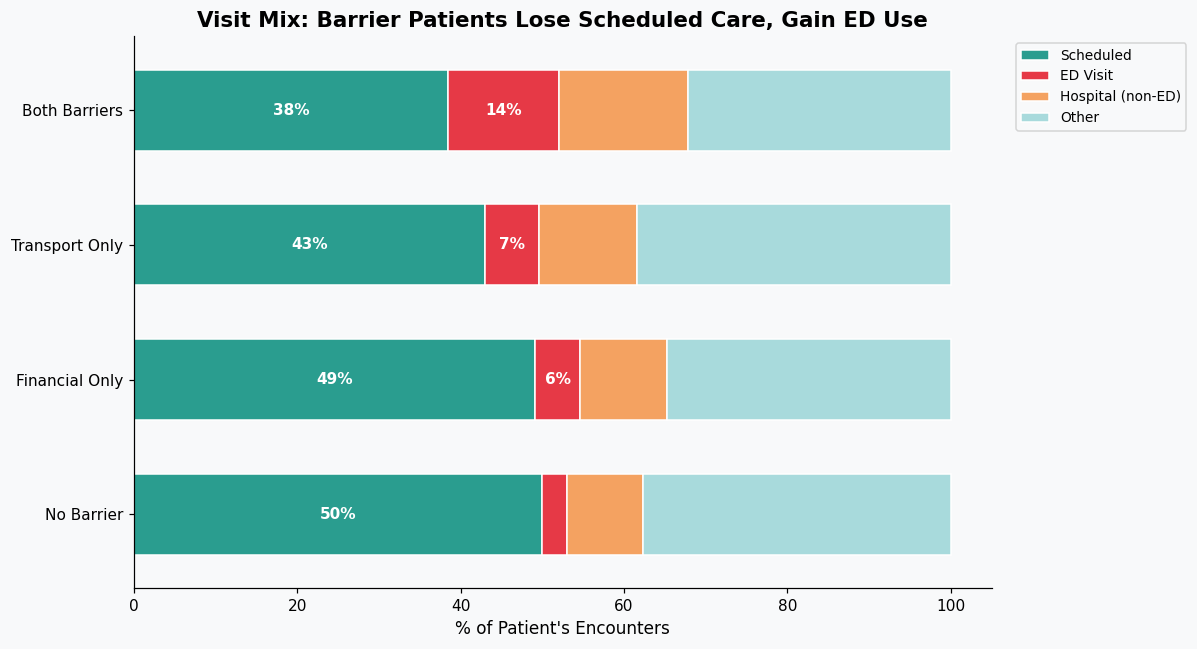

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))
mix_colors = [C_OK, C_ED, C_WARN, '#A8DADC']
mix_summary.plot(kind='barh', stacked=True, ax=ax, color=mix_colors, 
                 edgecolor='white', width=0.6)
ax.set_xlabel('% of Patient\'s Encounters', fontsize=11)
ax.set_title('Visit Mix: Barrier Patients Lose Scheduled Care, Gain ED Use',
             fontsize=14, fontweight='bold')
ax.legend(['Scheduled','ED Visit','Hospital (non-ED)','Other'],
          bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.set_ylabel('')

# Annotate scheduled and ED percentages
for i, group in enumerate(mix_summary.index):
    sched = mix_summary.loc[group, 'Scheduled_pct']
    ed = mix_summary.loc[group, 'ED Visit_pct']
    ax.text(sched/2, i, f'{sched:.0f}%', ha='center', va='center', 
            color='white', fontweight='bold', fontsize=10)
    if ed > 4:
        ax.text(sched + ed/2, i, f'{ed:.0f}%', ha='center', va='center',
                color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### 💡 Interpretation

The ranking is consistent across the gradient:

- **No Barrier**: 50% scheduled, 3% ED
- **Financial Only**: ~49% scheduled, ~5% ED
- **Transport Only**: 41% scheduled, 10% ED
- **Both Barriers**: lowest scheduled share, highest ED share

Each additional barrier shifts the visit mix toward emergency care. Transport barriers do this more sharply than financial barriers, but having both is the worst combination.

This is the worst possible outcome for both sides. For the patient, ED care is reactive, fragmented, and often comes after avoidable suffering. For SVH, ED care costs an order of magnitude more than scheduled office visits. Social barriers don't reduce demand — they redirect it to the most expensive, least efficient channel.

## 2.3 — The Cost: $4 Million per Year

We can put a dollar figure on this. Using national HCUP data, the average ED visit costs roughly **$2,200**, while an office visit costs about **$250**. If transport-barrier patients used the ED at the same rate as no-barrier patients, how much would SVH save?

In [14]:
# Compute avoidable ED for transport-affected patients (Transport Only + Both Barriers)
baseline_rate = patient_ed[patient_ed['barrier_group']=='No Barrier']['ed_rate'].mean() / 100

# Combine all transport-affected patients (Transport Only + Both Barriers)
transport_affected = patient_ed[patient_ed['barrier_group'].isin(['Transport Only','Both Barriers'])]
actual_ed = transport_affected['ed'].sum()
expected_ed = (transport_affected['total'] * baseline_rate).sum()
excess_ed = actual_ed - expected_ed

ED_COST = 2200
OFFICE_COST = 250
savings_per_visit = ED_COST - OFFICE_COST
total_savings = excess_ed * savings_per_visit
annual_savings = total_savings / 4

print('=== AVOIDABLE ED VISIT ESTIMATION (4 years) ===')
print(f'Baseline ED rate (no barrier):       {baseline_rate*100:.1f}%')
print(f'Transport-affected patients:         {len(transport_affected):,}')
print(f'  (Transport Only + Both Barriers)')
print(f'\nActual ED visits (barrier):          {actual_ed:>10,.0f}')
print(f'Expected at baseline rate:           {expected_ed:>10,.0f}')
print(f'Excess (avoidable) ED visits:        {excess_ed:>10,.0f}')
print(f'\nCost per redirected visit:           ${savings_per_visit:>9,}')
print(f'4-year potential savings:            ${total_savings:>13,.0f}')
print(f'Annual potential savings:            ${annual_savings:>13,.0f}')

=== AVOIDABLE ED VISIT ESTIMATION (4 years) ===
Baseline ED rate (no barrier):       3.1%
Transport-affected patients:         2,986
  (Transport Only + Both Barriers)

Actual ED visits (barrier):              14,408
Expected at baseline rate:                6,204
Excess (avoidable) ED visits:             8,204

Cost per redirected visit:           $    1,950
4-year potential savings:            $   15,997,283
Annual potential savings:            $    3,999,321


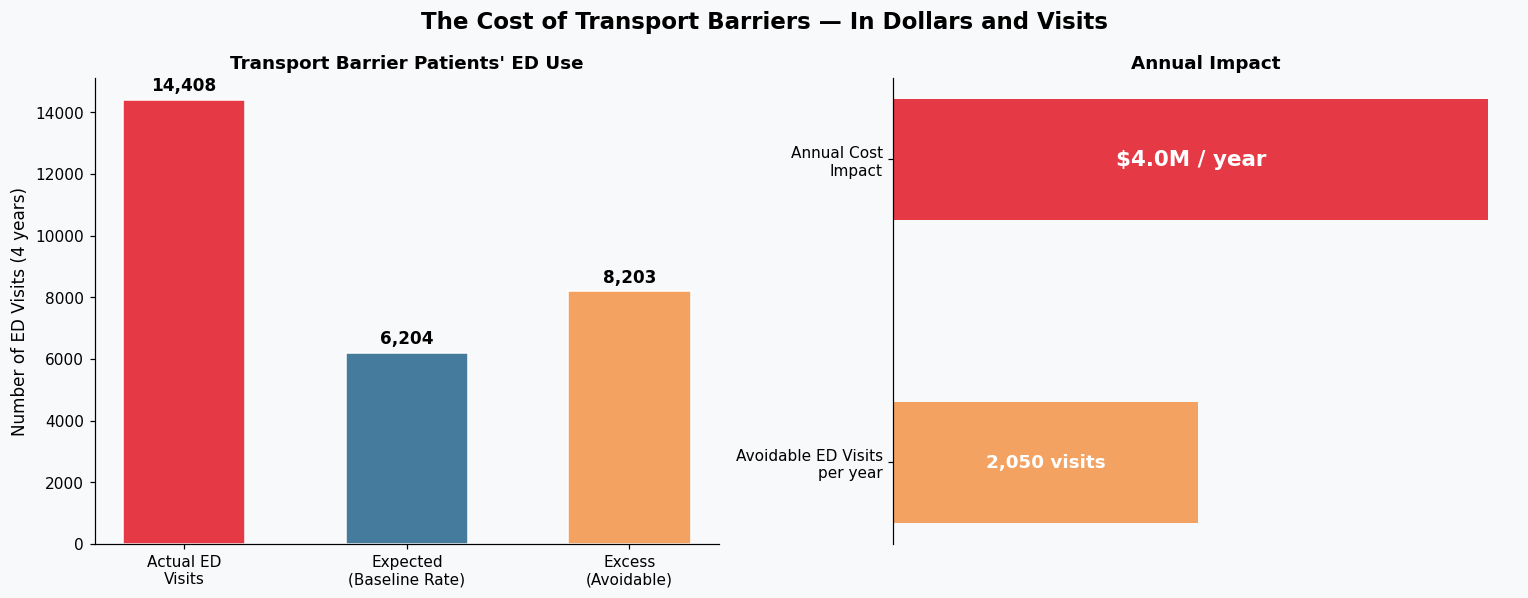

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('The Cost of Transport Barriers — In Dollars and Visits',
             fontsize=15, fontweight='bold')

# Left: ED visit count breakdown
ax = axes[0]
labels = ['Actual ED\nVisits', 'Expected\n(Baseline Rate)', 'Excess\n(Avoidable)']
vals = [actual_ed, expected_ed, excess_ed]
colors_c = [C_ED, C_OUT, C_WARN]
bars = ax.bar(labels, vals, color=colors_c, edgecolor='white', width=0.55)
ax.set_ylabel('Number of ED Visits (4 years)', fontsize=11)
ax.set_title('Transport Barrier Patients\' ED Use', fontweight='bold', fontsize=12)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v + max(vals)*0.02, f'{int(v):,}',
            ha='center', fontweight='bold', fontsize=11)

# Right: Cost waterfall
ax = axes[1]
ax.barh(['Avoidable ED Visits\nper year'], [excess_ed/4], color=C_WARN, height=0.4)
ax.text(excess_ed/4/2, 0, f'{int(excess_ed/4):,} visits', 
        ha='center', va='center', fontweight='bold', fontsize=12, color='white')
ax.barh(['Annual Cost\nImpact'], [annual_savings/1000], color=C_ED, height=0.4)
ax.text(annual_savings/1000/2, 1, f'${annual_savings/1e6:.1f}M / year',
        ha='center', va='center', fontweight='bold', fontsize=14, color='white')
ax.set_title('Annual Impact', fontweight='bold', fontsize=12)
ax.set_xticks([])
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()

### 💡 Interpretation

If transport-barrier patients used the ED at the same rate as no-barrier patients, SVH would have **8,204 fewer ED visits over four years** — about **2,050 per year**. At an estimated $1,950 cost difference between an ED visit and an equivalent office visit, that's roughly **$4 million per year** in potentially avoidable cost.

**Important caveats:**
- The cost figures are national-average estimates ([HCUP](https://www.hcup-us.ahrq.gov/)). SVH-specific costs may vary.
- Not every barrier-patient ED visit is truly avoidable — some emergencies are real emergencies.
- Even if only 25% of these visits are preventable, that's still $1M/year.

But the order of magnitude is clear: this is a multi-million-dollar problem hiding in plain sight.

---

# 🛠️ ACT III — The Solution

## 3.1 — MyChart as Mitigation

If transport is the barrier, then **digital access** could partially substitute for physical access. SVH already has MyChart — a patient portal for messaging providers, viewing results, requesting refills, and scheduling appointments. Does it actually help barrier patients?

In [16]:
# MyChart effect among ALL transport-affected patients (Transport Only + Both)
transport_affected_set = transport_barrier_set  # this already includes both groups
tb_patients = df_pat[df_pat['DurableKey'].isin(transport_affected_set)].copy()
tb_patients['mychart_active'] = tb_patients['MyChartStatus'] == 'Activated'

tb_enc = df_enc[df_enc['PatientDurableKey'].isin(transport_affected_set)]
tb_ed = tb_enc.groupby('PatientDurableKey').agg(
    total=('EncounterKey','count'),
    ed=('IsEdVisit','sum')
).reset_index()
tb_ed['ed_rate'] = tb_ed['ed'] / tb_ed['total'] * 100
tb_ed = tb_ed.merge(tb_patients[['DurableKey','mychart_active']],
                    left_on='PatientDurableKey', right_on='DurableKey', how='inner')

mychart_effect = tb_ed.groupby('mychart_active')['ed_rate'].agg(['mean','count'])
mychart_effect.index = ['No MyChart','MyChart Active']
print('=== MYCHART EFFECT ON TRANSPORT-AFFECTED PATIENTS ===')
print(mychart_effect.round(2))
reduction = (mychart_effect.loc['No MyChart','mean'] - mychart_effect.loc['MyChart Active','mean']) / mychart_effect.loc['No MyChart','mean'] * 100
print(f'\n→ MyChart-active barrier patients have {reduction:.0f}% lower ED rate.')

=== MYCHART EFFECT ON TRANSPORT-AFFECTED PATIENTS ===
                mean  count
No MyChart     13.54    981
MyChart Active  8.56   1999

→ MyChart-active barrier patients have 37% lower ED rate.


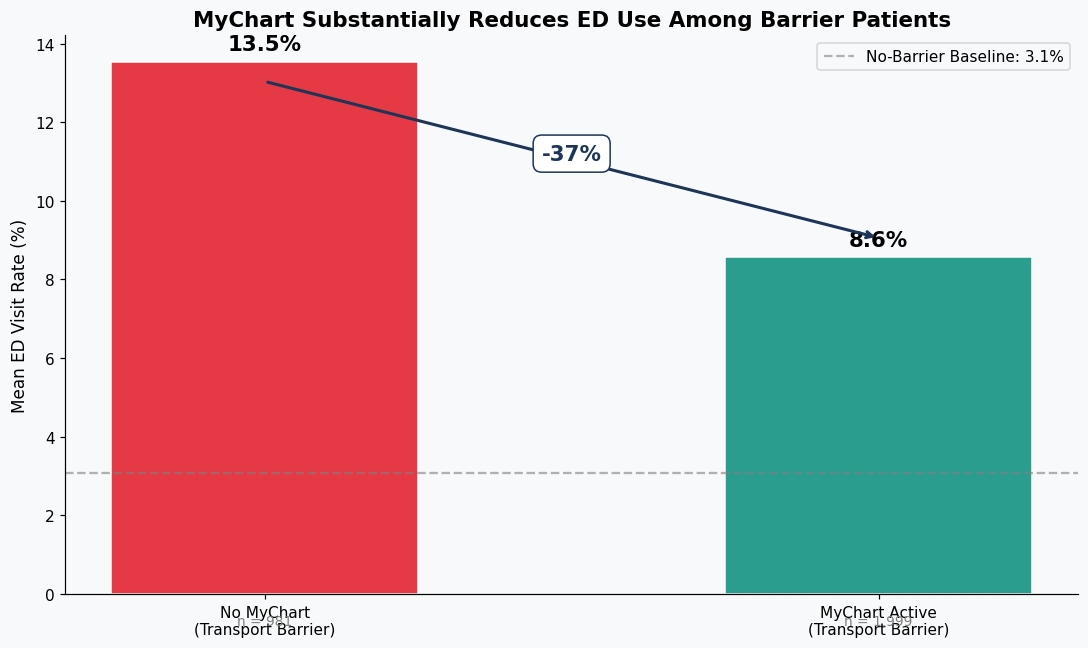

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
groups = ['No MyChart\n(Transport Barrier)', 'MyChart Active\n(Transport Barrier)']
values = mychart_effect['mean'].values
colors_m = [C_ED, C_OK]

bars = ax.bar(groups, values, color=colors_m, edgecolor='white', width=0.5)
ax.set_ylabel('Mean ED Visit Rate (%)', fontsize=11)
ax.set_title('MyChart Substantially Reduces ED Use Among Barrier Patients',
             fontsize=14, fontweight='bold')

for b, v, n in zip(bars, values, mychart_effect['count']):
    ax.text(b.get_x()+b.get_width()/2, v+0.3, f'{v:.1f}%',
            ha='center', fontweight='bold', fontsize=14)
    ax.text(b.get_x()+b.get_width()/2, -0.8, f'n = {int(n):,}',
            ha='center', fontsize=9, color='grey')

# Baseline reference
ax.axhline(y=baseline_rate*100, color='grey', linestyle='--', alpha=0.6,
           label=f'No-Barrier Baseline: {baseline_rate*100:.1f}%')
ax.legend(loc='upper right', fontsize=10)

# Reduction annotation
ax.annotate('', xy=(1, values[1]+0.5), xytext=(0, values[0]-0.5),
            arrowprops=dict(arrowstyle='->', color='#1d3557', lw=2))
ax.text(0.5, (values[0]+values[1])/2, f'-{reduction:.0f}%',
        ha='center', fontweight='bold', fontsize=14, color='#1d3557',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#1d3557'))

plt.tight_layout()
plt.show()

### 💡 Interpretation

Among transport-barrier patients, those with active MyChart accounts have an ED rate of **8.6%**, compared to **13.5%** for those without MyChart — a **37% reduction**. The barrier hasn't disappeared, but its impact is materially smaller.

MyChart can't drive a patient to the hospital — but it can:
- Enable secure messaging with providers (avoiding unnecessary visits)
- Allow medication refills without an in-person trip
- Enable telehealth appointments
- Provide test results and care instructions remotely

Note one caveat: this is correlational. Patients who set up MyChart may be self-selected (more digitally engaged in general). But the magnitude of the effect, combined with the plausible mechanism, makes MyChart adoption a strong candidate for intervention.

## 3.2 — Geographic Hotspots: Where to Deploy

In [18]:
# Barrier rate per block group, with location
pat_barrier = df_pat[['DurableKey','fips_bg']].merge(
    barrier_df[['PatientDurableKey','has_transport']],
    left_on='DurableKey', right_on='PatientDurableKey', how='inner'
)
bg_stats = pat_barrier.groupby('fips_bg').agg(
    total_surveyed=('DurableKey','count'),
    transport_barrier=('has_transport','sum')
).reset_index()
bg_stats['barrier_pct'] = bg_stats['transport_barrier'] / bg_stats['total_surveyed'] * 100
bg_stats = bg_stats[bg_stats['total_surveyed'] >= 10]

bg_geo = bg_stats.merge(df_tiger[['GEOID','CENTLAT','CENTLON']],
                        left_on='fips_bg', right_on='GEOID', how='inner')

print(f'Block groups analyzed (≥10 surveyed patients): {len(bg_geo)}')
print(f'\nTop 5 barrier hotspots:')
for _, r in bg_geo.nlargest(5, 'barrier_pct').iterrows():
    print(f'  FIPS {r["fips_bg"]}: {r["barrier_pct"]:.1f}% ({int(r["transport_barrier"])}/{int(r["total_surveyed"])} patients)')

Block groups analyzed (≥10 surveyed patients): 404

Top 5 barrier hotspots:
  FIPS 201770008004: 34.5% (30/87 patients)
  FIPS 201770040004: 22.8% (13/57 patients)
  FIPS 200610005002: 21.6% (11/51 patients)
  FIPS 201770012001: 21.0% (13/62 patients)
  FIPS 201770004003: 20.6% (21/102 patients)


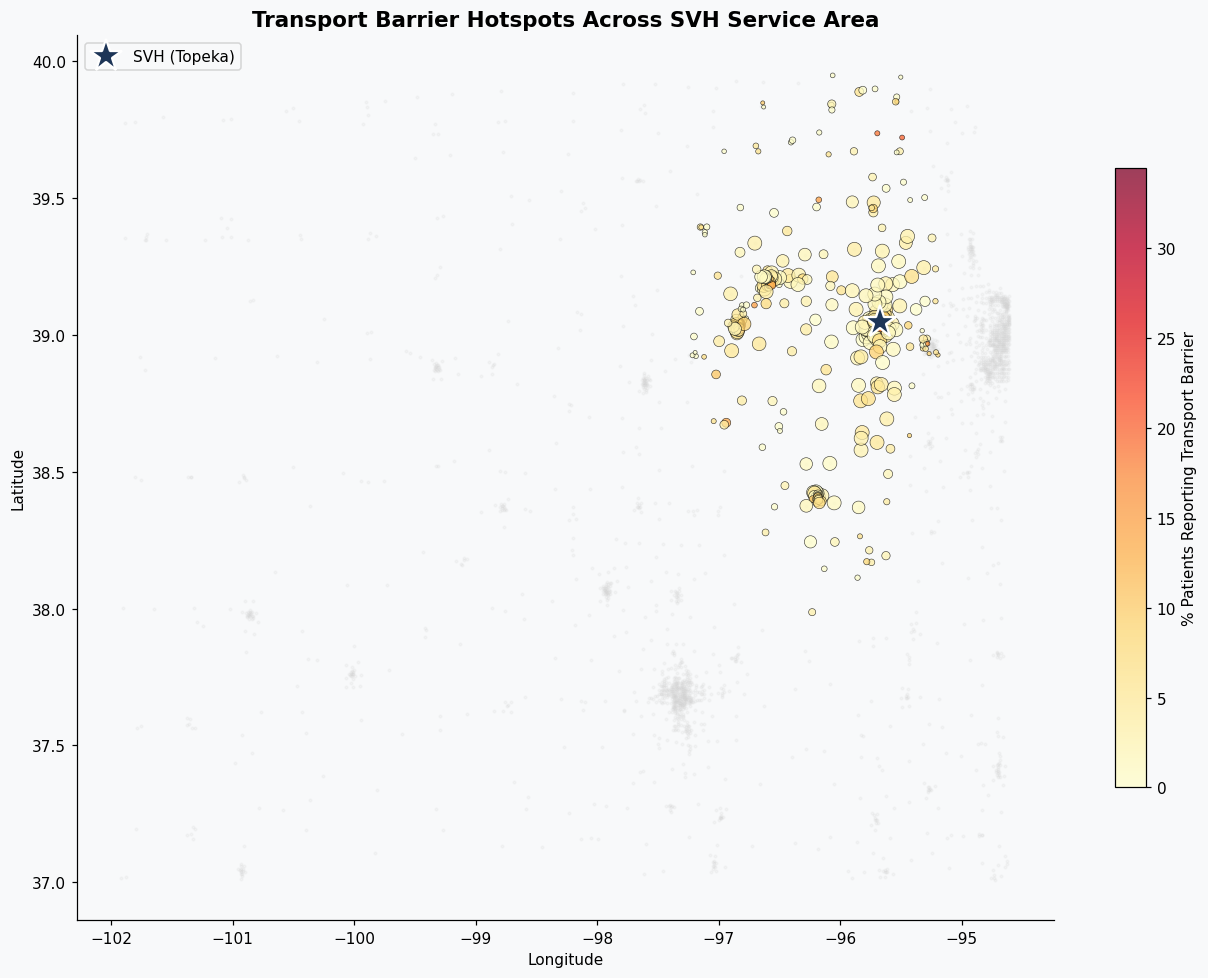

In [19]:
fig, ax = plt.subplots(figsize=(12, 9))

# All block groups (background)
all_tiger = df_tiger.dropna(subset=['CENTLAT','CENTLON'])
ax.scatter(all_tiger['CENTLON'], all_tiger['CENTLAT'],
           s=3, alpha=0.15, color='lightgrey')

# Block groups with barrier data
scatter = ax.scatter(bg_geo['CENTLON'], bg_geo['CENTLAT'],
                     c=bg_geo['barrier_pct'], cmap='YlOrRd',
                     s=bg_geo['total_surveyed'].clip(upper=120) * 0.7,
                     alpha=0.75, edgecolors='black', linewidth=0.4)
cbar = plt.colorbar(scatter, label='% Patients Reporting Transport Barrier',
                    shrink=0.7, ax=ax)

ax.plot(SVH_LON, SVH_LAT, '*', color='#1d3557', markersize=22,
        markeredgecolor='white', markeredgewidth=1.5, label='SVH (Topeka)', zorder=5)
ax.set_title('Transport Barrier Hotspots Across SVH Service Area',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

### 💡 Interpretation

Transport barriers are not evenly distributed. The top hotspot block groups have barrier rates above **20% of surveyed patients** — four times the system average. Many of these cluster in **Shawnee County** (around Topeka), which is counterintuitive given proximity to SVH headquarters. This suggests urban transit gaps and low car ownership in specific neighborhoods, not just rural distance.

For SVH, this is operationally actionable: a **mobile clinic** or **ride-share program** doesn't need to be deployed everywhere. Targeting the top 10–20 hotspot block groups would reach the highest-need patients with the lowest deployment cost.

## 3.3 — System-Side Bottlenecks: Even "Ideal" Patients Wait

Before we conclude, one important check: is the entire problem patient-side (transport, finances), or does SVH itself have capacity issues? We isolate **"ideal" patients** — those with no barriers AND active MyChart — and ask: where do *they* still experience long gaps between visits?

In [20]:
# Build journey table to compute Gap Days (within journey = patient + diagnosis)
df_j = df_enc[df_enc['PrimaryDiagnosisKey'] != -1][
    ['EncounterKey','PatientDurableKey','PrimaryDiagnosisKey','Date','DepartmentKey','IsEdVisit']
].copy()
df_j = df_j.merge(df_diag[['DiagnosisKey','DiagnosisValue','GroupName']],
                  left_on='PrimaryDiagnosisKey', right_on='DiagnosisKey', how='inner')
df_j = df_j.sort_values(['PatientDurableKey','DiagnosisValue','Date'])
df_j['Prev_Date'] = df_j.groupby(['PatientDurableKey','DiagnosisValue'])['Date'].shift(1)
df_j['Gap_Days'] = (df_j['Date'] - df_j['Prev_Date']).dt.days

# Define ideal patients
activated = set(df_pat[df_pat['MyChartStatus']=='Activated']['DurableKey'])
no_barrier = set(barrier_df[(~barrier_df['has_transport']) & 
                            (~barrier_df['has_financial'])]['PatientDurableKey'])
ideal_set = activated & no_barrier

print(f'Activated patients:           {len(activated):,}')
print(f'No-barrier (surveyed):        {len(no_barrier):,}')
print(f'"Ideal" (both):               {len(ideal_set):,}')

Activated patients:           274,082
No-barrier (surveyed):        55,519
"Ideal" (both):               47,025


In [21]:
# Bottleneck by department specialty (ideal patients only)
ideal_dept = df_j[df_j['PatientDurableKey'].isin(ideal_set)].merge(
    df_dept[['DepartmentKey','DepartmentSpecialty']], on='DepartmentKey', how='left'
)
dept_bn = ideal_dept[ideal_dept['Gap_Days'] > 0].groupby('DepartmentSpecialty')['Gap_Days'].agg(
    ['mean','median','count']
)
dept_bn = dept_bn[dept_bn['count'] >= 100].sort_values('mean', ascending=False).head(8)
print('=== TOP 8 SLOWEST SPECIALTIES (Ideal Patients) ===')
print(dept_bn.round(1))

=== TOP 8 SLOWEST SPECIALTIES (Ideal Patients) ===
                      mean  median  count
DepartmentSpecialty                      
Urgent Care         322.20  236.00   6577
Pulmonology         260.10  245.00  11919
Family Medicine     244.50  194.00  79276
Allergy             229.60  184.00   2959
Emergency Medicine  222.80  104.00   5537
Pediatrics          220.30  168.00    641
Dermatology         210.10  133.00  14688
Internal Medicine   208.70  127.00  42113


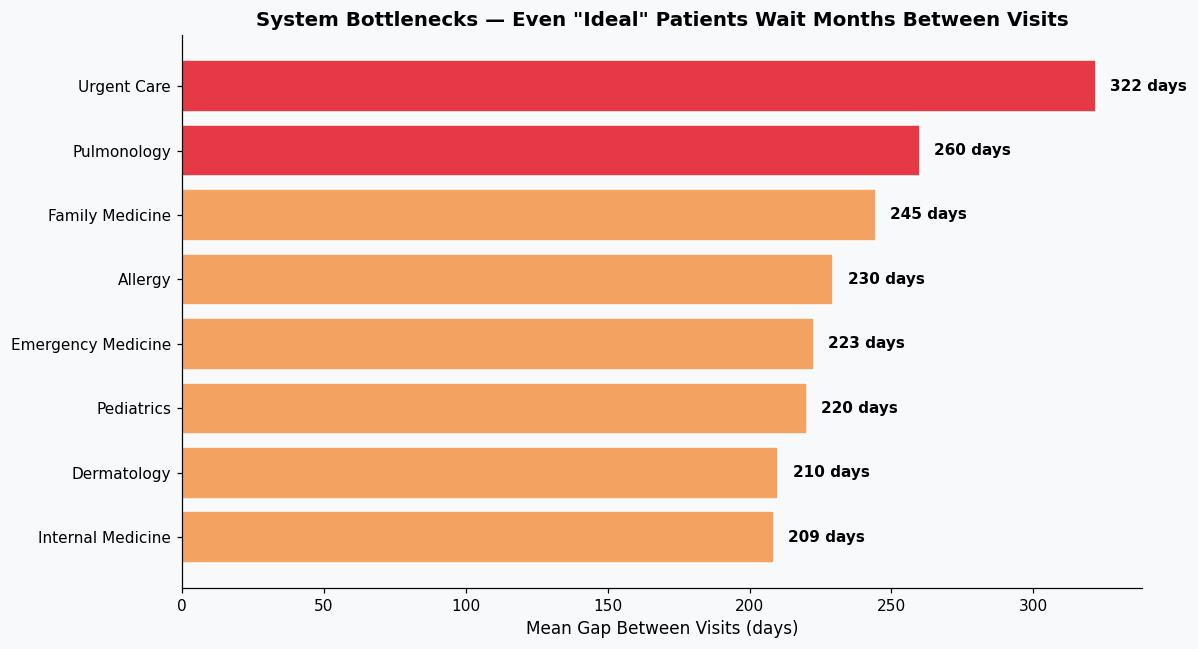

In [22]:
fig, ax = plt.subplots(figsize=(11, 6))
specialties = dept_bn.index.tolist()
values = dept_bn['mean'].values

bars = ax.barh(range(len(specialties)), values, 
               color=[C_ED if v > 250 else C_WARN if v > 200 else C_OUT for v in values],
               edgecolor='white')
ax.set_yticks(range(len(specialties)))
ax.set_yticklabels(specialties, fontsize=10)
ax.set_xlabel('Mean Gap Between Visits (days)', fontsize=11)
ax.set_title('System Bottlenecks — Even "Ideal" Patients Wait Months Between Visits',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()

for b, v in zip(bars, values):
    ax.text(v + 5, b.get_y() + b.get_height()/2, f'{v:.0f} days',
            va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### 💡 Interpretation

Even patients with no social barriers and active digital engagement still face long waits in certain specialties. **Urgent Care averages 322 days between visits**, **Pulmonology 260 days**, **Family Medicine 245 days**. These aren't transportation problems — they're **capacity problems**.

This matters for our story because it tells us **transport intervention alone won't solve everything**. A patient who can finally make it to their pulmonologist's office still has to wait months for an appointment. Solving the transportation barrier without addressing capacity bottlenecks would be like fixing a leaking pipe but leaving the empty water tank.

**Pulmonology is particularly notable** — it's both a system bottleneck (260-day gaps for ideal patients) AND a chronic disease where transport barriers cause the biggest ED rate increase (COPD jumps +18.5pp). The same specialty that needs transport help also needs capacity expansion.

---

# 🎯 EPILOGUE — Three Recommendations for SVH

<div style="background: #F8F9FA; padding: 30px; border-radius: 10px; border-left: 5px solid #E63946;">

## The Story in One Sentence

> **Transport-barrier patients aren't reducing their use of SVH — they're shifting it to the most expensive door (the ED), at a 3.3× rate that costs an estimated $4M/year in avoidable spending.**

</div>

## Recommendation 1 — Ride-Share Partnership for High-Risk Chronic Patients

**Target:** COPD, Anxiety, Asthma patients flagged with transport barriers via SDOH survey.

**Why:** These three conditions show the largest ED-rate gap when transportation is missing (+11.9 to +18.5 percentage points). Cutting trips to ED for COPD alone could prevent both medical deterioration and ICU admissions.

**Mechanism:** Partner with [Lyft Healthcare](https://www.lyft.com/hub/healthcare) or Uber Health for non-emergency medical transportation, integrated into the appointment scheduling workflow. SVH staff books the ride at the same time as booking the visit.

**Cost-benefit:** A medical Lyft ride costs ~$15–25. Even at the upper end, replacing 100 ED visits with 100 office visits + ride-share saves SVH ~$192,500 (= 100 × ($1,950 − $25)). At the estimated 2,050 avoidable visits per year, this is a high-ROI intervention.

## Recommendation 2 — Targeted MyChart Enrollment Campaign

**Target:** Transport-barrier patients without active MyChart accounts (currently ~1,000 patients).

**Why:** MyChart-active barrier patients have a 37% lower ED rate than non-active barrier patients. This is the largest single mitigation factor we identified, and SVH already owns the infrastructure.

**Mechanism:** During the SDOH survey itself, when a patient marks "Yes" to a transport question, the workflow triggers a MyChart enrollment offer — including in-person setup help by social workers and a print-out tutorial for less digitally fluent patients. Pair with telehealth eligibility check.

## Recommendation 3 — Mobile Clinic Pilot in Top 10 Hotspot Block Groups

**Target:** The 10 block groups with the highest measured transport-barrier rates (mostly in Shawnee County urban gaps).

**Why:** Hotspots are concentrated, not dispersed. A small fleet (1–2 mobile units) covering specific neighborhoods on rotating schedules could reach hundreds of high-barrier patients.

**Mechanism:** Mobile primary-care + specialty consult units, integrated with SVH's records. Schedule visits via MyChart for patients who can use it, via direct outreach for those who can't.

## What This Investigation Did NOT Find

- **Income alone doesn't predict ED use** — once transport is controlled for, income quartile flattens. Medicaid coverage in Kansas likely buffers this.
- **Rural/urban distinction is weaker than expected** — barrier hotspots are urban as often as rural. The story is access, not distance.
- **Financial barriers matter, but less than transport** — ED rate gap is +10pp for financial vs +14pp for transport. Both deserve attention; transport is the bigger lever.

---
## 📋 Methodology Summary

**Data sources:**
- 7 internal SVH datasets (encounters, patients, diagnosis, departments, providers, social_determinants, tigercensuscodes)
- ACS 5-Year 2023 estimates (B19013 income, B08201 vehicles, B27001 insurance) from data.census.gov

**Key definitions:**
- **Journey** = sequence of encounters linked by `(PatientDurableKey, DiagnosisValue)`
- **Gap Days** = days between consecutive encounters within the same journey (not across diagnoses)
- **Transport Barrier** = patient answered "Yes" to either transportation survey question (not based on whether the survey was administered)
- **Ideal Patient** = no transport or financial barrier AND MyChart status = "Activated"

**Validation:**
- ACS Census vehicle data (collected independently of SVH) shows the same gradient pattern as the SVH internal survey, confirming the barrier classification is real.

**Limitations:**
- SDOH survey only covers 17% of patients with encounters. Findings generalize to surveyed patients; broader generalization assumes random survey sampling.
- Cost figures use national HCUP averages, not SVH-specific costs.
- Correlational findings (e.g., MyChart effect) cannot rule out self-selection. Causal claims would require an RCT or natural experiment.

**Reproducibility:**
- All analysis runs in this single notebook. No hidden state, no manual data cleaning steps. Sample sizes and counts are reported alongside every comparison.